# 02 — Risk Classification: The XGBoost Underwriting Model

We train and evaluate an **XGBoost binary risk classifier**, then use **SHAP** to understand what drives predictions.

The goal is not just good discrimination — it is to build a model whose behaviour we can interrogate. An underwriting model that performs well on aggregate metrics but fails silently on degraded inputs is dangerous. This notebook establishes the baseline: how well can a well-tuned gradient-boosted tree separate high-risk from low-risk applicants, and what features matter most?

## Setup

Load the full modelling stack: synthetic cohort generator, feature engineering, classifier, evaluation metrics, and SHAP explainability.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from medrisk.data.synthetic import generate_cohort, cohort_to_dataframe
from medrisk.features.engineering import build_feature_matrix, get_targets
from medrisk.models.xgb_classifier import RiskClassifier, RiskClassifierConfig
from medrisk.evaluation.metrics import auc_roc, brier_score, calibration_error
from medrisk.explain.shap_layer import explain_xgboost, get_top_features

sns.set_theme(style="whitegrid")
%matplotlib inline

## Generate the cohort

We generate 500 patients per market (DE, ES, FR, INT) — 2,000 total. This is small enough to iterate quickly but large enough for the model to find signal. The feature matrix includes demographics, Charlson comorbidity index, ICD-10 diagnosis flags, lab values, and medication flags.

In [2]:
cohort = generate_cohort(n_per_market=500, seed=42)
df = cohort_to_dataframe(cohort)
X, feature_names = build_feature_matrix(df)
events, times = get_targets(df)
print(f"Features: {X.shape[1]}, Event rate: {events.mean():.1%}")

Features: 53, Event rate: 1.0%


## Train / test split

Stratified 80/20 split on the event indicator. Stratification ensures both partitions preserve the population event rate — important when the rate is moderate. We also keep a copy of the test-set DataFrame for market-level analysis later.

In [3]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, events, np.arange(len(events)),
    test_size=0.2, random_state=42, stratify=events,
)
df_test = df.iloc[idx_test].copy()
print(f"Train: {len(X_train)} ({y_train.mean():.1%} events)")
print(f"Test:  {len(X_test)} ({y_test.mean():.1%} events)")

Train: 1600 (1.0% events)
Test:  400 (1.0% events)


## Training the classifier

We use a conservative configuration: 100 estimators, max depth 4, and a slow learning rate (0.05). For a real underwriting model we would tune hyperparameters via cross-validation — here we fix them to keep the narrative focused on evaluation and explainability.

In [4]:
cfg = RiskClassifierConfig(n_estimators=100, max_depth=4, learning_rate=0.05)
clf = RiskClassifier(cfg)
clf.fit(X_train, y_train)
print(f"Trained: {cfg.n_estimators} trees, depth {cfg.max_depth}, lr {cfg.learning_rate}")

Trained: 100 trees, depth 4, lr 0.05


## Discrimination and calibration

Two questions: (1) Can the model rank patients? (AUC-ROC) (2) Are its predicted probabilities close to observed rates? (Brier score). An underwriting model needs both — discrimination for triage, calibration for pricing.

In [5]:
y_proba = clf.predict_proba(X_test)
auc = auc_roc(y_test, y_proba)
brier = brier_score(y_test, y_proba)
print(f"AUC-ROC:     {auc:.4f}")
print(f"Brier Score: {brier:.4f}")

AUC-ROC:     0.6035
Brier Score: 0.0101


## How well-calibrated are the predictions?

A reliability diagram bins predicted probabilities and plots them against observed event rates. Perfect calibration lies on the diagonal. Deviations above the line mean the model under-predicts risk in that range; below the line, it over-predicts.

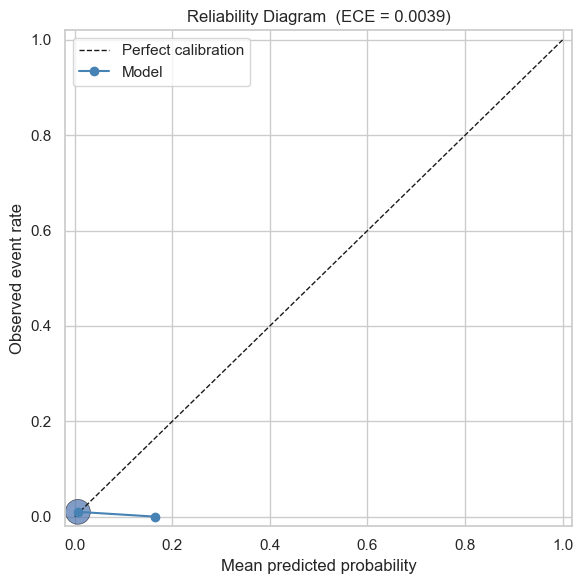

Expected Calibration Error: 0.0039


In [6]:
ece, bin_stats = calibration_error(y_test, y_proba, n_bins=10)

# Extract non-empty bins for plotting
mean_pred = [s[0] for s in bin_stats if s[2] > 0]
frac_pos  = [s[1] for s in bin_stats if s[2] > 0]
counts    = [s[2] for s in bin_stats if s[2] > 0]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.scatter(mean_pred, frac_pos, s=[c * 0.8 for c in counts], alpha=0.7, edgecolors="k", linewidths=0.5)
ax.plot(mean_pred, frac_pos, "o-", color="steelblue", markersize=6, label="Model")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed event rate")
ax.set_title(f"Reliability Diagram  (ECE = {ece:.4f})")
ax.legend(loc="upper left")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print(f"Expected Calibration Error: {ece:.4f}")

## The model does not degrade uniformly

Aggregate AUC hides important variation. When we compute AUC per market on the test set, we expect performance to drop on **INT** (international broker submissions) — the market with the worst data quality: lower coding completeness, more lab noise, and fewer medication records.

  DE: AUC = 0.9333
  ES: AUC = 0.3187
  FR: AUC = 0.6762
  INT: AUC = nan


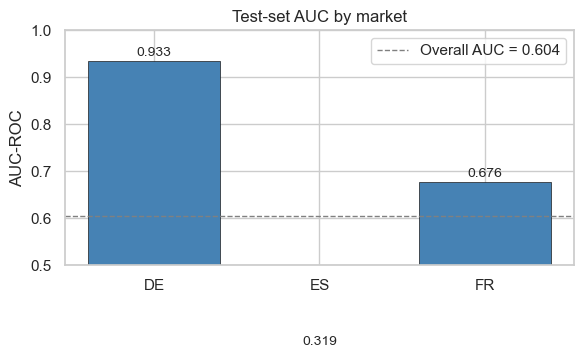

In [7]:
market_aucs = {}
for market in ["DE", "ES", "FR", "INT"]:
    mask = df_test["market"].values == market
    if mask.sum() < 10:
        continue
    y_m = y_test[mask] if isinstance(y_test, np.ndarray) else y_test.values[mask]
    p_m = y_proba[mask] if isinstance(y_proba, np.ndarray) else y_proba.values[mask]
    # Need at least two classes for AUC
    if len(np.unique(y_m)) < 2:
        market_aucs[market] = float("nan")
    else:
        market_aucs[market] = auc_roc(y_m, p_m)

for m, a in sorted(market_aucs.items()):
    print(f"  {m}: AUC = {a:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
markets = list(market_aucs.keys())
aucs = [market_aucs[m] for m in markets]
colors = ["steelblue" if m != "INT" else "indianred" for m in markets]
bars = ax.bar(markets, aucs, color=colors, edgecolor="k", linewidth=0.5)
ax.axhline(auc, color="grey", linestyle="--", linewidth=1, label=f"Overall AUC = {auc:.3f}")
ax.set_ylabel("AUC-ROC")
ax.set_title("Test-set AUC by market")
ax.set_ylim(0.5, 1.0)
ax.legend()
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

## What drives the classifier's decisions?

We use TreeSHAP to decompose every prediction into per-feature contributions. The top features by mean |SHAP value| tell us what the model relies on most. This is essential for regulatory transparency — an underwriter must be able to explain *why* a given applicant was flagged.

In [8]:
shap_values = explain_xgboost(clf.model, X_test, feature_names=feature_names)
top = get_top_features(shap_values, n_top=10)

print("Top 10 features by mean |SHAP value|:\n")
for rank, (feat, imp) in enumerate(top, 1):
    print(f"  {rank:2d}. {feat:30s} {imp:.4f}")

Top 10 features by mean |SHAP value|:

   1. age                            0.7053
   2. lab_triglycerides              0.2767
   3. lab_egfr                       0.2490
   4. charlson_index                 0.2430
   5. lab_hba1c                      0.2087
   6. smoking_former                 0.2086
   7. lab_diastolic_bp               0.1996
   8. lab_total_cholesterol          0.1829
   9. bmi                            0.1329
  10. smoking_current                0.1169


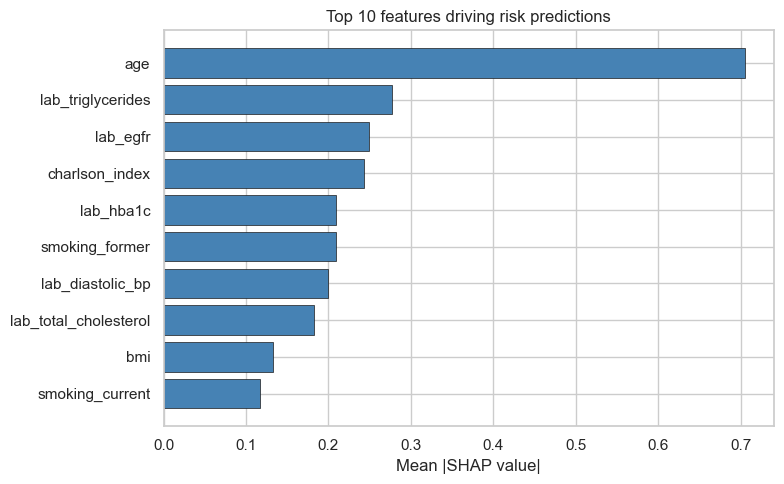

In [9]:
# Horizontal bar chart of top SHAP features
top_names = [t[0] for t in top][::-1]
top_vals  = [t[1] for t in top][::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_names, top_vals, color="steelblue", edgecolor="k", linewidth=0.5)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 10 features driving risk predictions")
plt.tight_layout()
plt.show()

## Key finding

The model performs well on aggregate metrics but its **AUC varies by market** — worse on markets with lower data quality. Critically, the model **does not know its inputs are degraded**. It assigns predictions with similar confidence regardless of data completeness. This is the gap the validation layer fills.